In [1]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_d1ca81f52ce7e0566dd7581667088132'


In [2]:
!pip install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.20
    Uninstalling kagglesdk-0.1.20:
      Successfully uninstalled kagglesdk-0.1.20
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [3]:
# Download EuroSAT
!kaggle datasets download -d apollo2506/eurosat-dataset

# Unzip in current directory
!unzip -q eurosat-dataset.zip -d .

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:25<00:00, 86.7MB/s]



In [4]:
# Download NWPU-RESISC45
!kaggle datasets download -d aqibrehmanpirzada/nwpuresisc45

# Unzip in current directory
!unzip -q nwpuresisc45.zip -d .

Dataset URL: https://www.kaggle.com/datasets/aqibrehmanpirzada/nwpuresisc45
License(s): unknown
100% 408M/408M [00:03<00:00, 141MB/s]



**Imports**

In [5]:
import os
import random
import torch
import numpy as np

from PIL import Image
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

**Dataset Classes**

In [6]:
EUROSAT_CLASSES = [
    "River",
    "Forest",
    "Residential",
    "AnnualCrop",
]

NWPU_SUBSET = [
    "airport",
    "beach",
    "forest",
    "harbor",
    "stadium"
]

**Prompt Pools**

In [7]:
BLIP2_PROMPTS = [

    """
    Question: Which class best describes this satellite image?
    Choices: {labels}
    Answer with only one class name.
    """,

    """
    Question: Identify the land-use category in this remote sensing image.
    Options: {labels}
    Respond using one label only.
    """,

    """
    Question: This aerial image belongs to which category?
    Classes: {labels}
    Only output the class name.
    """,

    """
    Question: What is the correct scene category for this satellite image?
    Candidate labels: {labels}
    Answer using exactly one label.
    """,

    """
    Question: Analyze this remote sensing image and determine its class.
    Available classes: {labels}
    Return only the predicted category.
    """,

    """
    Question: Which land-cover type is shown in this aerial image?
    Labels: {labels}
    Respond with a single class name only.
    """,

    """
    Question: Select the most appropriate category for this satellite scene.
    Categories: {labels}
    Output only one category.
    """,

    """
    Question: What environment or land-use class is represented in this image?
    Possible labels: {labels}
    Answer with one label only.
    """,

    """
    Question: Determine the scene classification of this remote sensing image.
    Classes available: {labels}
    Provide only the class name.
    """,

    """
    Question: Classify this Earth observation image.
    Choices are: {labels}
    Return exactly one class label.
    """,

    """
    Question: Which category best matches the content of this aerial photograph?
    Options: {labels}
    Respond with only one option.
    """,

    """
    Question: Predict the land-use classification for this satellite image.
    Candidate categories: {labels}
    Give only one category name.
    """,

    """
    Question: Identify the scene type shown in this remote sensing image.
    Possible classes: {labels}
    Return one label only.
    """,

    """
    Question: Which label correctly describes this Earth surface image?
    Labels: {labels}
    Answer using a single label only.
    """,

    """
    Question: Assign this satellite image to the correct category.
    Available options: {labels}
    Only provide the class name.
    """,

    """
    Question: What type of scene is visible in this aerial image?
    Candidate labels: {labels}
    Respond with one category only.
    """,

    """
    Question: Choose the correct remote sensing category for this image.
    Categories: {labels}
    Output one label only.
    """,

    """
    Question: Identify the dominant land-use class in this image.
    Possible answers: {labels}
    Return a single class label.
    """,

    """
    Question: What is the most likely classification of this satellite image?
    Choices: {labels}
    Give only one answer.
    """,

    """
    Question: Determine which category this remote sensing image belongs to.
    Labels available: {labels}
    Respond with only the category name.
    """
]

In [8]:
LLAVA_PROMPTS = [

    """
    USER: <image>
    Which class best describes this satellite image?
    Choices: {labels}
    Answer with one class only.
    ASSISTANT:
    """,

    """
    USER: <image>
    Identify the remote sensing category.
    Options: {labels}
    Return only one label.
    ASSISTANT:
    """,

    """
    USER: <image>
    Classify this aerial image into one category:
    {labels}
    ASSISTANT:
    """,

    """
    USER: <image>
    What is the correct scene category for this satellite image?
    Candidate labels: {labels}
    Answer using exactly one label.
    ASSISTANT:
    """,

    """
    USER: <image>
    Analyze this remote sensing image and determine its class.
    Available classes: {labels}
    Return only the predicted category.
    ASSISTANT:
    """,

    """
    USER: <image>
    Which land-cover type is shown in this aerial image?
    Labels: {labels}
    Respond with a single class name only.
    ASSISTANT:
    """,

    """
    USER: <image>
    Select the most appropriate category for this satellite scene.
    Categories: {labels}
    Output only one category.
    ASSISTANT:
    """,

    """
    USER: <image>
    What environment or land-use class is represented in this image?
    Possible labels: {labels}
    Answer with one label only.
    ASSISTANT:
    """,

    """
    USER: <image>
    Determine the scene classification of this remote sensing image.
    Classes available: {labels}
    Provide only the class name.
    ASSISTANT:
    """,

    """
    USER: <image>
    Classify this Earth observation image.
    Choices are: {labels}
    Return exactly one class label.
    ASSISTANT:
    """,

    """
    USER: <image>
    Which category best matches the content of this aerial photograph?
    Options: {labels}
    Respond with only one option.
    ASSISTANT:
    """,

    """
    USER: <image>
    Predict the land-use classification for this satellite image.
    Candidate categories: {labels}
    Give only one category name.
    ASSISTANT:
    """,

    """
    USER: <image>
    Identify the scene type shown in this remote sensing image.
    Possible classes: {labels}
    Return one label only.
    ASSISTANT:
    """,

    """
    USER: <image>
    Which label correctly describes this Earth surface image?
    Labels: {labels}
    Answer using a single label only.
    ASSISTANT:
    """,

    """
    USER: <image>
    Assign this satellite image to the correct category.
    Available options: {labels}
    Only provide the class name.
    ASSISTANT:
    """,

    """
    USER: <image>
    What type of scene is visible in this aerial image?
    Candidate labels: {labels}
    Respond with one category only.
    ASSISTANT:
    """,

    """
    USER: <image>
    Choose the correct remote sensing category for this image.
    Categories: {labels}
    Output one label only.
    ASSISTANT:
    """,

    """
    USER: <image>
    Identify the dominant land-use class in this image.
    Possible answers: {labels}
    Return a single class label.
    ASSISTANT:
    """,

    """
    USER: <image>
    What is the most likely classification of this satellite image?
    Choices: {labels}
    Give only one answer.
    ASSISTANT:
    """,

    """
    USER: <image>
    Determine which category this remote sensing image belongs to.
    Labels available: {labels}
    Respond with only the category name.
    ASSISTANT:
    """
]

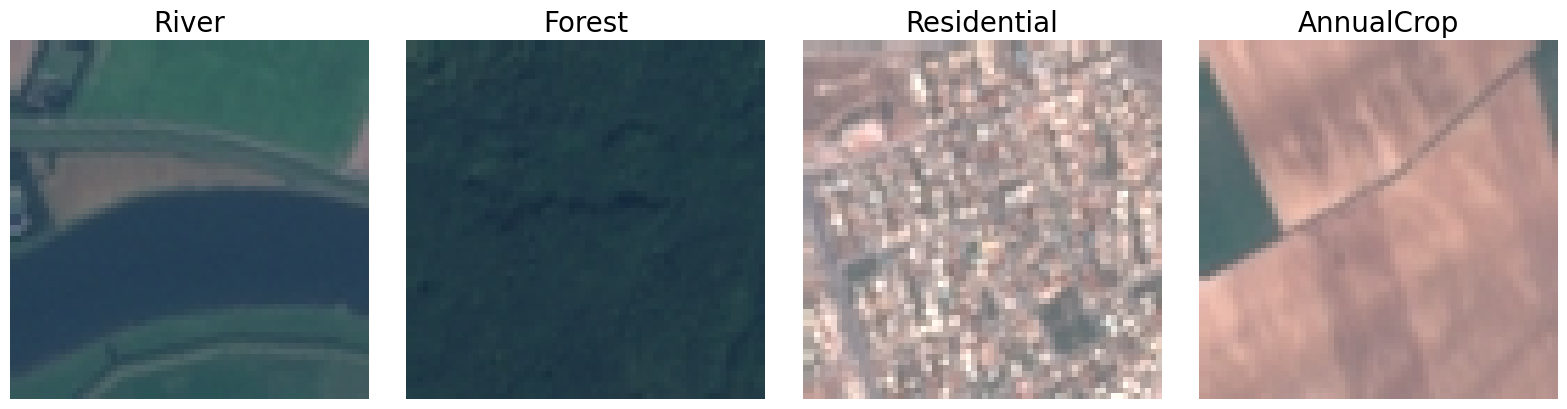

In [ ]:
EUROSAT_PATH = "EuroSAT"

plt.figure(figsize=(16, 4))

for i, class_name in enumerate(EUROSAT_CLASSES):

    class_dir = os.path.join(EUROSAT_PATH, class_name)

    image_name = random.choice(os.listdir(class_dir))

    image_path = os.path.join(class_dir, image_name)

    image = Image.open(image_path)

    plt.subplot(1, 4, i + 1)

    plt.imshow(image)

    plt.title(class_name,fontsize=20)

    plt.axis("off")

plt.tight_layout()

plt.show()

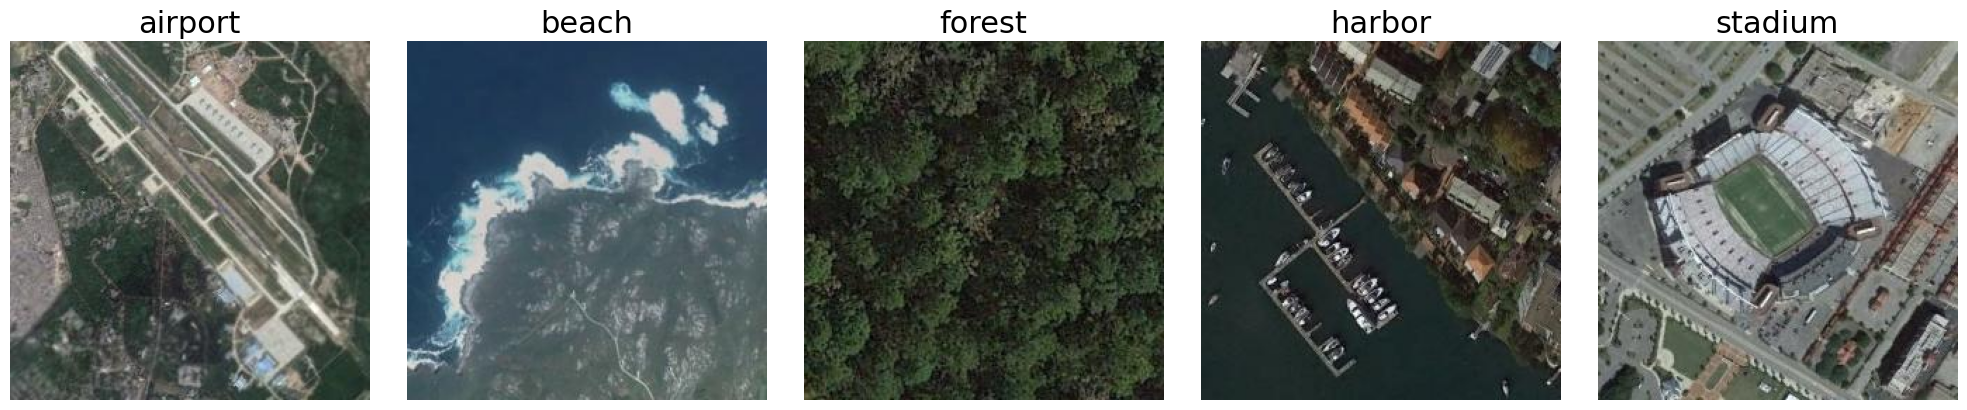

In [ ]:
NWPU_PATH = "Dataset/test/test"

plt.figure(figsize=(20, 4))

for i, class_name in enumerate(NWPU_SUBSET):

    class_dir = os.path.join(NWPU_PATH, class_name)

    image_name = random.choice(os.listdir(class_dir))

    image_path = os.path.join(class_dir, image_name)

    image = Image.open(image_path)

    plt.subplot(1, 5, i + 1)

    plt.imshow(image)

    plt.title(class_name, fontsize=22)

    plt.axis("off")

plt.tight_layout()

plt.show()

**Dataset Loader**

In [9]:
def load_dataset(dataset_path, labels, percentage=10):

    samples = []

    # normalize labels for matching
    normalized_labels = {
        label.lower(): label
        for label in labels
    }

    for folder_name in os.listdir(dataset_path):

        class_dir = os.path.join(dataset_path, folder_name)

        if not os.path.isdir(class_dir):
            continue

        # normalize folder name
        normalized_folder = folder_name.lower().strip()

        # skip folders not in labels list
        if normalized_folder not in normalized_labels:
            continue

        # use official label name from labels list
        class_name = normalized_labels[normalized_folder]

        class_samples = []

        for image_name in os.listdir(class_dir):

            image_path = os.path.join(class_dir, image_name)

            class_samples.append((image_path, class_name))

        # shuffle class images
        random.shuffle(class_samples)

        # select x%
        num_samples = int(
            len(class_samples) * (percentage / 100)
        )

        # keep subset
        class_samples = class_samples[:num_samples]

        samples.extend(class_samples)

    # shuffle final dataset
    random.shuffle(samples)

    return samples

In [10]:
def evaluate_model(y_true, y_pred, labels, model_name,dataset_name):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n===== {model_name} =====")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")

    print("\nClassification Report:\n")

    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 25}   # values inside boxes
    )

    # Title font size
    plt.title(f"{model_name} Confusion Matrix on {dataset_name}", fontsize=20)

    # Axis label font sizes
    plt.xlabel("Predicted", fontsize=20)
    plt.ylabel("Actual", fontsize=20)

    # Class names font sizes
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.show()

In [11]:
import re

def format_label(label):

    # convert CamelCase -> space separated
    label = re.sub(r'(?<!^)(?=[A-Z])', ' ', label)

    # replace separators
    label = label.replace("_", " ")
    label = label.replace("-", " ")
    label = label.replace("/", " ")

    # lowercase
    label = label.lower()

    # remove extra spaces
    label = " ".join(label.split())

    return label

**Initialize CLIP**

In [ ]:
from transformers import pipeline

clip_model = pipeline(
    task="zero-shot-image-classification",
    model="openai/clip-vit-base-patch32",
    device=0
)

In [28]:
def classify_clip(dataset_path, labels,dataset_name="", percentage=10):

    samples = load_dataset(dataset_path,labels,percentage)

    y_true = []
    y_pred = []

    for image_path, actual_label in tqdm(samples):

        result = clip_model(
            image_path,
            candidate_labels=labels
        )

        prediction = result[0]["label"]

        y_true.append(actual_label)
        y_pred.append(prediction)

    evaluate_model(
        y_true,
        y_pred,
        labels,
        "CLIP",
        dataset_name
    )

**Run CLIP**

100%|██████████| 1150/1150 [00:29<00:00, 39.40it/s]



===== CLIP =====
Accuracy  : 0.6226
Precision : 0.7650
Recall    : 0.6226
F1-score  : 0.5791

Classification Report:

              precision    recall  f1-score   support

  AnnualCrop       0.46      0.93      0.61       300
      Forest       0.90      0.25      0.39       300
 Residential       0.75      0.97      0.85       300
       River       0.99      0.29      0.45       250

    accuracy                           0.62      1150
   macro avg       0.77      0.61      0.57      1150
weighted avg       0.77      0.62      0.58      1150



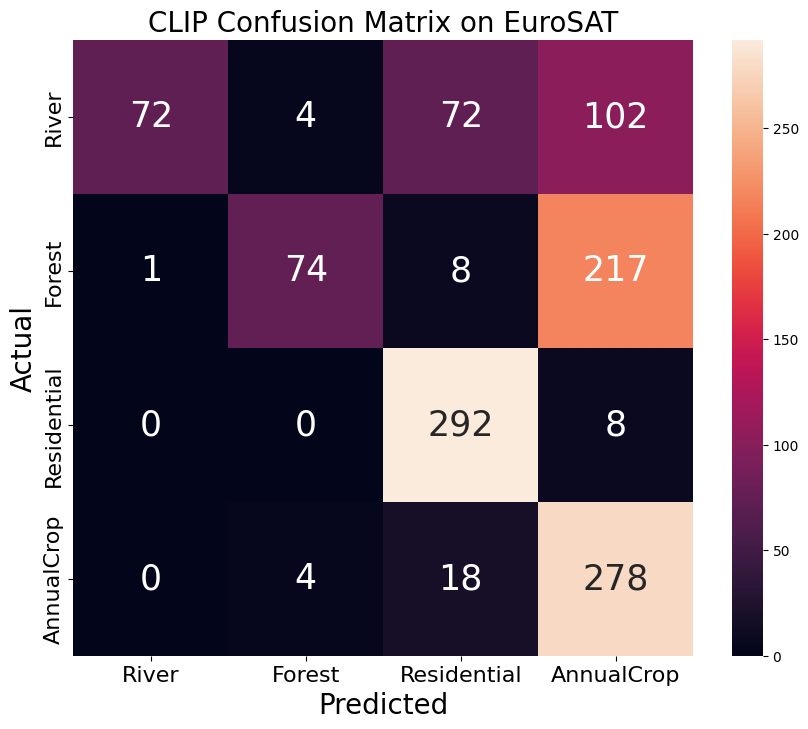

In [32]:
classify_clip(
    "EuroSAT",
    EUROSAT_CLASSES,
    dataset_name="EuroSAT",
    percentage=10
)

100%|██████████| 600/600 [00:14<00:00, 40.19it/s]



===== CLIP =====
Accuracy  : 0.9850
Precision : 0.9852
Recall    : 0.9850
F1-score  : 0.9850

Classification Report:

              precision    recall  f1-score   support

     airport       0.97      0.99      0.98       120
       beach       1.00      0.97      0.99       120
      forest       1.00      0.99      1.00       120
      harbor       0.97      0.97      0.97       120
     stadium       0.99      1.00      1.00       120

    accuracy                           0.98       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.98      0.99       600



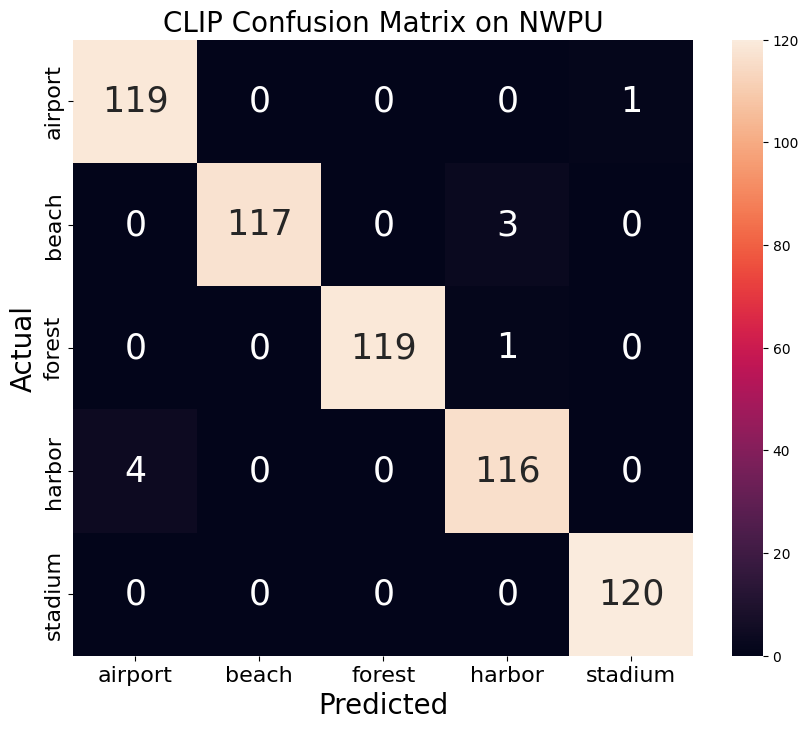

In [31]:
classify_clip(
    "Dataset/train/train",
    NWPU_SUBSET,
    dataset_name="NWPU",
    percentage=20
)

**Initialize BLIP-2**

In [33]:
from transformers import (
    Blip2Processor,
    Blip2ForConditionalGeneration
)

blip2_processor = Blip2Processor.from_pretrained(
    "Salesforce/blip2-flan-t5-xl"
)

blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-flan-t5-xl",
    torch_dtype=torch.float16,
    device_map="auto"
)

Loading weights:   0%|          | 0/1289 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

In [36]:
def classify_blip2(dataset_path, labels,dataset_name="", percentage=10):

    samples = load_dataset(
        dataset_path,
        labels,
        percentage
    )

    y_true = []
    y_pred = []

    labels_text = ", ".join((labels))
    labels_text = format_label(labels_text)
    for image_path, actual_label in tqdm(samples):

        image = Image.open(image_path).convert("RGB")

        # random prompt
        prompt_template = random.choice(BLIP2_PROMPTS)

        prompt = prompt_template.format(
            labels=labels_text
        )

        # preprocess
        inputs = blip2_processor(
            images=image,
            text=prompt,
            return_tensors="pt"
        ).to(blip2_model.device)

        # generate
        generated_ids = blip2_model.generate(
            **inputs,
            max_new_tokens=15,
        )

        # decode
        prediction = blip2_processor.batch_decode(
            generated_ids,
            skip_special_tokens=True
        )[0].strip()

        #print("\nraw prediction:", prediction)

        # normalized prediction
        normalized_prediction = (
            prediction.lower()
            .replace(" ", "")
            .replace("_", "")
            .replace("-", "")
            .replace("/", "")
        )

        matched_labels = []

        # search all labels
        for label in labels:

            normalized_label = (
                label.lower()
                .replace(" ", "")
                .replace("_", "")
                .replace("-", "")
                .replace("/", "")
            )

            if normalized_label in normalized_prediction:

                matched_labels.append(label)

        # choose best match
        if actual_label in matched_labels:

            matched_label = actual_label

        elif len(matched_labels) > 0:

            matched_label = matched_labels[0]

        else:

            matched_label = "Unknown"

        #print("matched labels:", matched_labels)
        #print("final predicted:", matched_label)
        #print("actual:", actual_label)
        #print("correct:", matched_label == actual_label)

        y_true.append(actual_label)
        y_pred.append(matched_label)

    evaluate_model(
        y_true,
        y_pred,
        labels,
        "BLIP-2",
        dataset_name
    )

**Run BLIP-2**

100%|██████████| 1150/1150 [10:03<00:00,  1.91it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== BLIP-2 =====
Accuracy  : 0.2365
Precision : 0.7816
Recall    : 0.2365
F1-score  : 0.2413

Classification Report:

              precision    recall  f1-score   support

  AnnualCrop       0.73      0.04      0.07       300
      Forest       0.81      0.18      0.29       300
 Residential       1.00      0.01      0.01       300
       River       0.55      0.82      0.66       250
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.24      1150
   macro avg       0.62      0.21      0.21      1150
weighted avg       0.78      0.24      0.24      1150



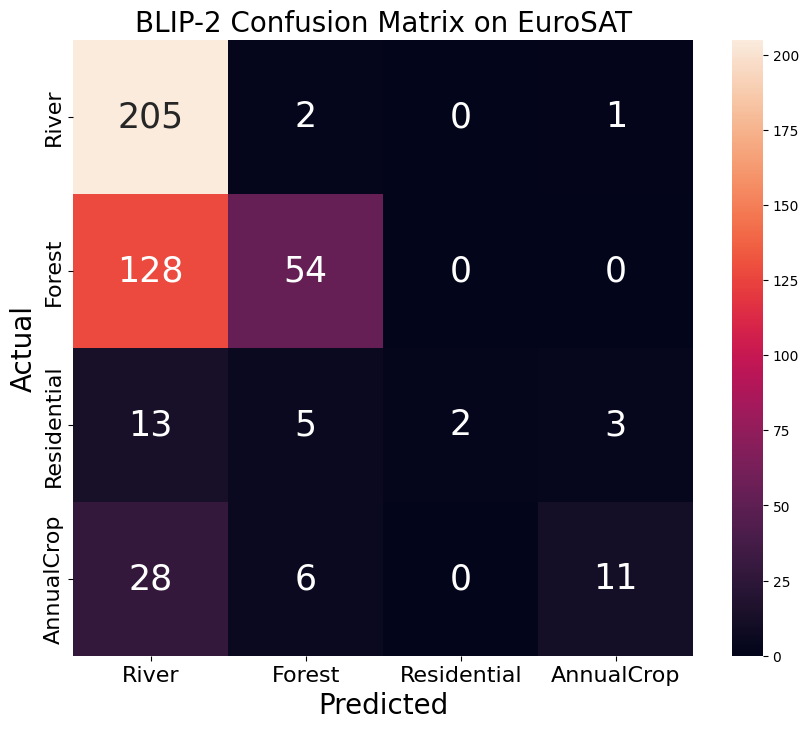

In [38]:
classify_blip2(
    "EuroSAT",
    EUROSAT_CLASSES,
    dataset_name="EuroSAT",
    percentage=10
)

100%|██████████| 600/600 [04:42<00:00,  2.12it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== BLIP-2 =====
Accuracy  : 0.5167
Precision : 0.9531
Recall    : 0.5167
F1-score  : 0.6448

Classification Report:

              precision    recall  f1-score   support

     Unknown       0.00      0.00      0.00         0
     airport       0.97      0.32      0.48       120
       beach       0.81      0.39      0.53       120
      forest       1.00      0.72      0.84       120
      harbor       1.00      0.31      0.47       120
     stadium       0.98      0.84      0.91       120

    accuracy                           0.52       600
   macro avg       0.79      0.43      0.54       600
weighted avg       0.95      0.52      0.64       600



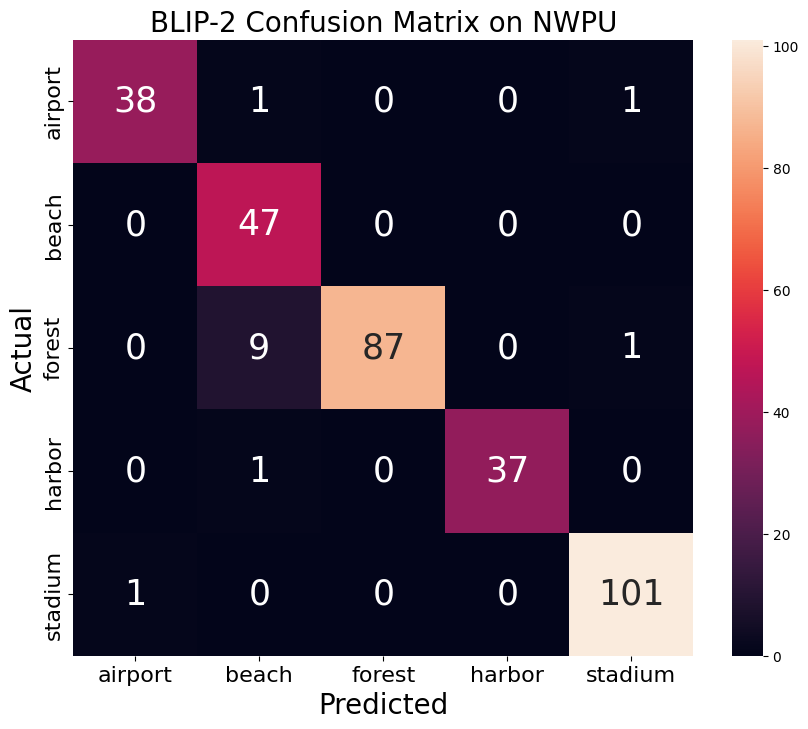

In [39]:
classify_blip2(
    "Dataset/train/train",
    NWPU_SUBSET,
    dataset_name="NWPU",
    percentage=20
)

**Initialize LLaVA**

In [12]:
from transformers import (
    AutoProcessor,
    LlavaForConditionalGeneration
)

model_id = "llava-hf/llava-1.5-7b-hf"

llava_processor = AutoProcessor.from_pretrained(
    model_id
)

llava_model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [13]:
def classify_llava(dataset_path, labels,dataset_name="", percentage=10):

    samples = load_dataset(dataset_path,labels, percentage)

    y_true = []
    y_pred = []

    labels_text = ", ".join(labels)
    labels_text = format_label(labels_text)
    for image_path, actual_label in tqdm(samples):

        image = Image.open(image_path).convert("RGB")

        prompt_template = random.choice(LLAVA_PROMPTS)

        prompt = prompt_template.format(
            labels=labels_text
        )

        inputs = llava_processor(
            text=prompt,
            images=image,
            return_tensors="pt"
        ).to(llava_model.device, torch.float16)

        output = llava_model.generate(
            **inputs,
            max_new_tokens=20
        )

        result = llava_processor.decode(
            output[0],
            skip_special_tokens=True
        )

        matched_label = "Unknown"

        if "ASSISTANT:" in result:
            result = result.split("ASSISTANT:")[-1]

        for label in labels:

            if label.lower() in result.lower():

                matched_label = label
                break

        y_true.append(actual_label)
        y_pred.append(matched_label)

    evaluate_model(
        y_true,
        y_pred,
        labels,
        "LLaVA",
        dataset_name
    )

**Run LLaVA**


100%|██████████| 1150/1150 [31:28<00:00,  1.64s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr


===== LLaVA =====
Accuracy  : 0.4426
Precision : 0.6256
Recall    : 0.4426
F1-score  : 0.5051

Classification Report:

              precision    recall  f1-score   support

  AnnualCrop       0.00      0.00      0.00       300
      Forest       0.94      0.51      0.66       300
 Residential       0.97      0.60      0.74       300
       River       0.58      0.70      0.64       250
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.44      1150
   macro avg       0.50      0.36      0.41      1150
weighted avg       0.63      0.44      0.51      1150



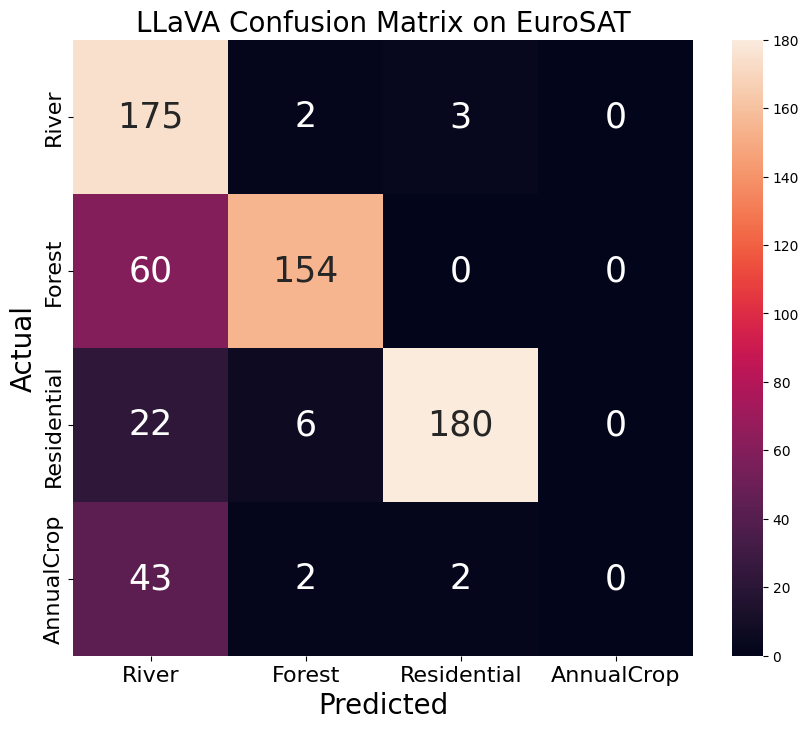

In [15]:
classify_llava(
    "EuroSAT",
    EUROSAT_CLASSES,
    dataset_name="EuroSAT",
    percentage=10
)

100%|██████████| 600/600 [12:53<00:00,  1.29s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== LLaVA =====
Accuracy  : 0.8850
Precision : 0.9611
Recall    : 0.8850
F1-score  : 0.9178

Classification Report:

              precision    recall  f1-score   support

     Unknown       0.00      0.00      0.00         0
     airport       0.94      1.00      0.97       120
       beach       1.00      0.77      0.87       120
      forest       0.89      0.71      0.79       120
      harbor       0.98      0.95      0.97       120
     stadium       1.00      1.00      1.00       120

    accuracy                           0.89       600
   macro avg       0.80      0.74      0.76       600
weighted avg       0.96      0.89      0.92       600



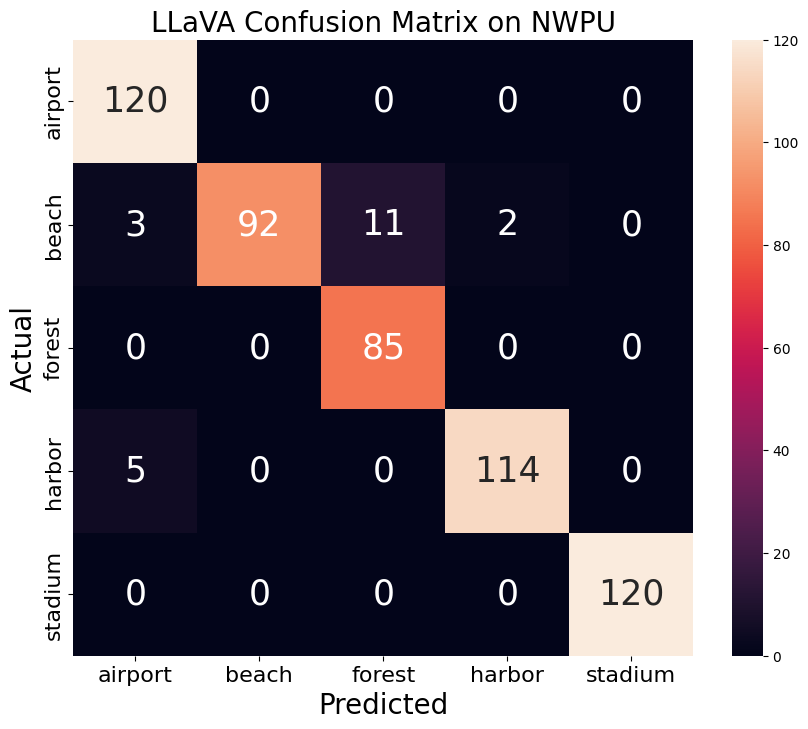

In [16]:
classify_llava(
    "Dataset/train/train",
    NWPU_SUBSET,
    dataset_name="NWPU",
    percentage=20
)

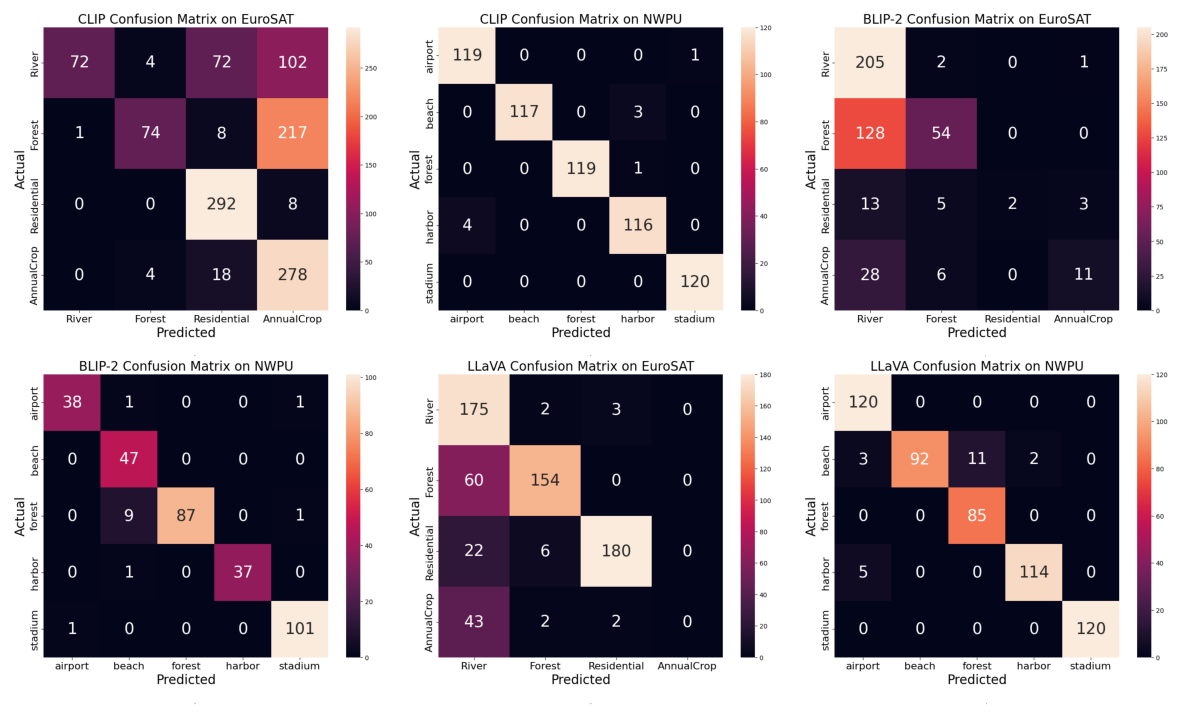

In [22]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Paths to your 6 images
image_paths = [
    "clip_eurosat.png", "clip_nwpu.png", "blip2_eurosat.png",
    "blip2_nwpu.png", "llava_eurosat.png", "llava_nwpu.png"
]

# Captions
captions = ['a', 'b', 'c', 'd', 'e', 'f']

# 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# Small horizontal & vertical spacing
plt.subplots_adjust(wspace=0.03, hspace=0.03)

for i, ax in enumerate(axes.flat):
    img = mpimg.imread(image_paths[i])

    ax.imshow(img)
    ax.axis('off')

    # Caption below image
    ax.text(
        0.5, -0.03,
        f"({captions[i]})",
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=0
    )

# Tight layout with small padding
plt.tight_layout(pad=0.3)

plt.show()